# Exercise 1

Deadline 6.11.2025

## 1. Two dimensional data

In [5]:
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt

from numpy import exp, sqrt, pi

In [6]:
# Plot
X, y = make_moons(n_samples = 500, noise = 0.1, random_state = 42)
#plt.scatter(X[:, 0], X[:, 1], s=10)

# Implement a class for each of the following models, including
# methods for fit(), sample(), and score_samples()

Next, we will implement classes, à la sklearn, providing methods for fit(), sample() and score_samples() without using the pre-defined classes, but formulating them independently.

We will create a class for each of the following models:

1. two-dimensional histogram
2. single Gaussian
3. Gaussian mixture model
4. kernel density estimator with a Gaussian kernel

For evaluation, we will implement the maximum mean discrepancy metric with squared exponential and inverse multi-quadratic kernels

$$ \mathrm{se}(x, x') = \mathrm{exp}(-\dfrac{||{x-x'}||^2}{h^2})$$

$$ \mathrm{imq}(x, x') = \dfrac{1}{\sqrt{1 + \dfrac{||{x-x'}||^2}{h^2}}}$$

### 1.1 Two dimensional histogram

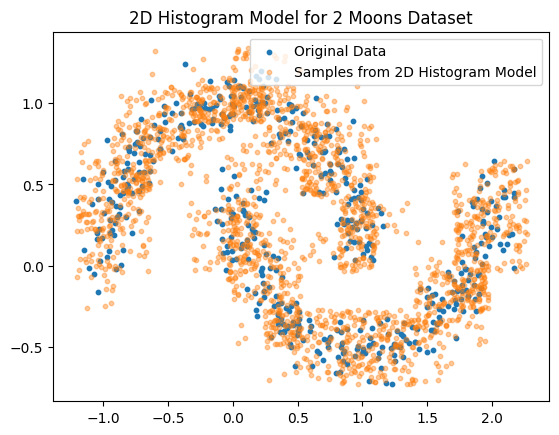

In [7]:
class two_dim_histogram:
    def __init__(self, random_state=None, bin_size=None):
        self.densities = None
        self.bin_edges_1 = None
        self.bin_edges_2 = None
        self.samples = None
        self.score = None
        self.log_density = None
        self.bin_indices = None
        self.bin_size = bin_size
        self.MMD_sq = None
        self.random_state = np.random.RandomState(random_state) if random_state is not None else np.random
    # Method to fit 2d histogram
    '''
    As in 1d, need to determine p_k and bin sizes.
    
    In 1d, determined the bin sizes with the interquantile range IQR

        h_1D = 2 IQR / (N)^(1/3)

    In 2d, do the same in both dimensions
    '''
    def fit(self, X): # training_data := X
        # Get n_samples
        n_samples = X.shape[0]

        # Determine Interquantile range
        # IQR = x_[3N/4] - x_[N/4]
        """
        DONT WANT TO GIVE PEOPLE THE OPTION TO PICK THEIR OWN BINS BECAUSE
        IM TOO TIRED 
        UGHH OK I NEED TO
        """
        if self.bin_size == None:
            IQR_x1 = np.percentile(X[:, 0], 75) - np.percentile(X[:, 0], 25)
            IQR_x2 = np.percentile(X[:, 1], 75) - np.percentile(X[:, 1], 25)

            # Bin widths
            h_1 = 2 * IQR_x1 / ((n_samples) ** (1/3))
            h_2 = 2 * IQR_x2 / ((n_samples) ** (1/3))
            self.bin_size = (np.round(h_1, 2), np.round(h_2, 2))

            # Create bins k
            x1_min, x1_max = np.min(X[:, 0]), np.max(X[:, 0])
            x2_min, x2_max = np.min(X[:, 1]), np.max(X[:, 1])
            self.bin_edges_1 = np.arange(x1_min, x1_max + self.bin_size[0], self.bin_size[0])
            self.bin_edges_2 = np.arange(x2_min, x2_max + self.bin_size[1], self.bin_size[1])
        else:
            x1_min, x1_max = np.min(X[:, 0]), np.max(X[:, 0])
            x2_min, x2_max = np.min(X[:, 1]), np.max(X[:, 1])
            self.bin_edges_1 = np.arange(x1_min, x1_max + self.bin_size[0], self.bin_size[0])
            self.bin_edges_2 = np.arange(x2_min, x2_max + self.bin_size[1], self.bin_size[1])
        
        # Determine counts in bins k
        counts, _, _ = np.histogram2d(X[:, 0], X[:, 1], bins = [self.bin_edges_1, self.bin_edges_2])
        self.densities = counts / counts.sum()

        return self.densities, self.bin_edges_1, self.bin_edges_2

    # Sample
    def sample(self, n_samples=1):
        # now we can draw samples from the learned histogram (generated new data points)
        probs_flat = self.densities.ravel()    # flatten the 2D probs array to 1D
        self.bin_indices = self.random_state.choice(probs_flat.size, size=n_samples, p=probs_flat)
        ix, iy = np.unravel_index(self.bin_indices, self.densities.shape) # convert flat indices back to 2D indices
        x0 = self.bin_edges_1[ix]
        x1 = self.bin_edges_1[ix + 1]
        y0 = self.bin_edges_2[iy]
        y1 = self.bin_edges_2[iy + 1]

        x_samples = x0 + self.random_state.rand(n_samples) * (x1 - x0)
        y_samples = y0 + self.random_state.rand(n_samples) * (y1 - y0)

        self.samples = np.column_stack([x_samples, y_samples])  # shape (n_samples, 2)

        return self.samples

    # Method to score samples
    def score_samples(self, X):
        """Compute the log density for each point in X."""
        if self.densities is None or self.bin_edges_1 is None or self.bin_edges_2 is None:
            raise ValueError("Model is not fitted. Call the `fit` method first.")

        # Find the bin indices for each point in X
        bin_indices_x = np.digitize(X[:, 0], self.bin_edges_1) - 1
        bin_indices_y = np.digitize(X[:, 1], self.bin_edges_2) - 1

        # Ensure indices are within range
        valid_mask = (
            (bin_indices_x >= 0) & (bin_indices_x < self.densities.shape[0]) &
            (bin_indices_y >= 0) & (bin_indices_y < self.densities.shape[1])
        )

        # Initialize log densities with -inf for points outside the histogram range
        self.log_densities = np.full(X.shape[0], -np.inf)

        # Assign log densities for valid points
        self.log_densities[valid_mask] = np.log(
            self.densities[bin_indices_x[valid_mask], bin_indices_y[valid_mask]]
        )

        return self.log_densities
        

    
    # Compute mmd^2
    def compute_mmd(self, X, h = 1, kernel = "squared_exponential"):
        if self.samples is None:
            raise ValueError("Samples are not generated. Call the `sample` method before scoring.")
        # Implement MMD^2 metric with se, imq kernels
        # Need to vectorize MMD calculation because for loops (sums) are very inefficient in python
        # MMD^2 = Term1 + Term2 - Term3, can neglect Term1 because it is model independent
        """
        MMD^2 = 0
        for i in range(1,N):
            for i_prime != i:
                MMD^2 += k(x_i, x_i_prime)

        for j in range(1, N_prime):
            for j_prime != j:
                MMD^2 += k(x_prime_j, x_prime_j_prime)

        for i in range(1, N):
            for j in range(1, N_prime):
                MMD^2 += -2 k(x_i, x_prime_j)
        """
        # Instead, we want to calculate it using something like this:
        """
        MMD^2 = k(distance_matrix_x).sum() 
            + k(distance_matrix_x_prime).sum() 
            - 2 k(distance_matrix_xx_prime).sum()
        """
        # Calculate Distance matrices D as: 
        # D[i, j] = || x_i - x_i_prime ||_2^2 = ||x||_2^2 + ||x_prime||_2^2 - 2 x.T @ x_prime
        # D_XX = self.calculate_distance_matrix(X, X) Can be neglected
        D_XprimeXprime = self.calculate_distance_matrix(self.samples, self.samples)
        D_XXprime = self.calculate_distance_matrix(X, self.samples)

        # Depending on selected kernel, calculate MMD^2
        N = X.shape[0]
        Nprime = self.samples.shape[0]
        if kernel == "squared_exponential":
            self.MMD_sq = (self.squared_exponential(D_XprimeXprime, h).sum() / (Nprime ** 2)
                      - 2 * self.squared_exponential(D_XXprime, h).sum() / (N * Nprime))
        elif kernel == "inverse_multi_quadratic":
            self.MMD_sq = (self.inverse_multi_quadratic(D_XprimeXprime, h).sum() / (Nprime ** 2)
                      - 2 * self.inverse_multi_quadratic(D_XXprime, h).sum() / (N * Nprime))
        else:
            raise ValueError("Please select either 'squared_exponential' or 'inverse_multi_quadratic'")
        """
        In the lecture we derived the formula where we sum over i, then sum over i != j. The kernels 
        k(i, i) are not 0, but 1. We still sum over them in the vectorization. For that reason, 
        we adjust the denominator to N^2, N'^2 instead of N(N-1), N'(N'-1)
        """

        self.MMD_sq

        return self.MMD_sq
    
    def calculate_distance_matrix(self, A, B):
        # D_ij = ||A_i - B_j||^2 = ||A_i||^2 + ||B_j||^2 - 2 A_i @ B_j.T
        # A_sq in (N_A, 1)
        A_sq = np.sum(A ** 2, axis = 1, keepdims = True)
        # B_sq in (1, N_B)
        B_sq = np.sum(B ** 2, axis = 1, keepdims = True).T # .T otherwise won't work if samples, data different dimension
        AB_T = A @ B.T
        D_AB = A_sq + B_sq - 2 * AB_T
        return D_AB
        
    def squared_exponential(self, D_AB, h):
        return exp(- D_AB / (h ** 2))   
    
    def inverse_multi_quadratic(self, D_AB, h):
        return 1 / sqrt(1 + D_AB / (h ** 2))

# Fit 2d histogram model
model = two_dim_histogram()
model.fit(X)
model.sample(2000)
model.score_samples(X)

make_moons_histogram2d, edges_1, edges_2 = model.fit(X)

# Sample from fitted model
X_samples = model.sample(n_samples = 2000)  

# Plot
plt.figure()
plt.title("2D Histogram Model for 2 Moons Dataset")
plt.scatter(X[:, 0], X[:, 1], s=10, label = "Original Data")
plt.scatter(X_samples[:, 0], X_samples[:, 1], s=10, alpha = 0.4, label = "Samples from 2D Histogram Model")
plt.legend()
plt.show()

# Score

### 1.2 Single Gaussian

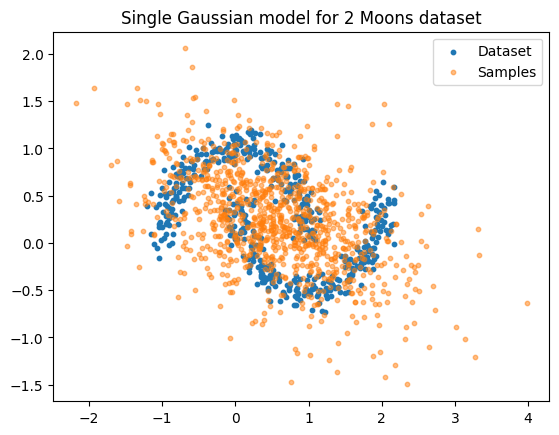

In [8]:
from scipy.stats import multivariate_normal

class single_gaussian:
    def __init__(self):
        self.mu = None
        self.Sigma = None
        self.samples = None
        self.score = None
        self.MMD_sq = None
        self.log_density = None
    # Method to fit a single Gaussian
    '''
    Need to determine appropriate mu, sigma for a single Gaussian on top of the data
    '''
    def fit(self, X): # training_data := X
        # Gaussian with simply mu = np.mean, Sigma = np.cov
        self.mu = np.mean(X, axis = 0)
        self.Sigma = np.cov(X, rowvar = False)

        return self.mu, self.Sigma
    
    def sample(self, n_samples):
        self.samples = np.random.multivariate_normal(self.mu, self.Sigma, n_samples)
        return self.samples

    def score_samples(self, X):
        """Compute the log density for each point in X."""
        if self.mu is None or self.Sigma is None:
            raise ValueError("Model parameters are not initialized. Call `fit` first.")

        # Compute the log density using the multivariate normal distribution
        self.log_density = multivariate_normal.logpdf(X, mean=self.mu, cov=self.Sigma)
        return self.log_density

    def compute_mmd(self, X, h = 1, kernel = "squared_exponential"):
        # Implement MMD^2 metric with se, imq kernels
        # Need to vectorize MMD calculation because for loops (sums) are very inefficient in python
        # MMD^2 = Term1 + Term2 - Term3, can neglect Term1 because it is model independent
        """
        MMD^2 = 0
        for i in range(1,N):
            for i_prime != i:
                MMD^2 += k(x_i, x_i_prime)

        for j in range(1, N_prime):
            for j_prime != j:
                MMD^2 += k(x_prime_j, x_prime_j_prime)

        for i in range(1, N):
            for j in range(1, N_prime):
                MMD^2 += -2 k(x_i, x_prime_j)
        """
        # Instead, we want to calculate it using something like this:
        """
        MMD^2 = k(distance_matrix_x).sum() 
            + k(distance_matrix_x_prime).sum() 
            - 2 k(distance_matrix_xx_prime).sum()
        """
        # Calculate Distance matrices D as: 
        # D[i, j] = || x_i - x_i_prime ||_2^2 = ||x||_2^2 + ||x_prime||_2^2 - 2 x.T @ x_prime
        # D_XX = self.calculate_distance_matrix(X, X) Can be neglected
        D_XprimeXprime = self.calculate_distance_matrix(self.samples, self.samples)
        D_XXprime = self.calculate_distance_matrix(X, self.samples)

        # Depending on selected kernel, calculate MMD^2
        N = X.shape[0]
        Nprime = self.samples.shape[0]
        if kernel == "squared_exponential":
            self.MMD_sq = (self.squared_exponential(D_XprimeXprime, h).sum() / (Nprime ** 2)
                      - 2 * self.squared_exponential(D_XXprime, h).sum() / (N * Nprime))
        elif kernel == "inverse_multi_quadratic":
            self.MMD_sq = (self.inverse_multi_quadratic(D_XprimeXprime, h).sum() / (Nprime ** 2)
                      - 2 * self.inverse_multi_quadratic(D_XXprime, h).sum() / (N * Nprime))
        else:
            raise ValueError("Please select either 'squared_exponential' or 'inverse_multi_quadratic'")
        """
        In the lecture we derived the formula where we sum over i, then sum over i != j. The kernels 
        k(i, i) are not 0, but 1. We still sum over them in the vectorization. For that reason, 
        we adjust the denominator to N^2, N'^2 instead of N(N-1), N'(N'-1)
        """

        self.MMD_sq

        return self.MMD_sq
    
    def calculate_distance_matrix(self, A, B):
        # D_ij = ||A_i - B_j||^2 = ||A_i||^2 + ||B_j||^2 - 2 A_i @ B_j.T
        # A_sq in (N_A, 1)
        A_sq = np.sum(A ** 2, axis = 1, keepdims = True)
        # B_sq in (1, N_B)
        B_sq = np.sum(B ** 2, axis = 1, keepdims = True).T # .T otherwise won't work if samples, data different dimension
        AB_T = A @ B.T
        D_AB = A_sq + B_sq - 2 * AB_T
        return D_AB
        
    def squared_exponential(self, D_AB, h):
        return exp(- D_AB / (h ** 2))   
    
    def inverse_multi_quadratic(self, D_AB, h):
        return 1 / sqrt(1 + D_AB / (h ** 2))

# Fit 2d single Gaussian model
model = single_gaussian()
make_moons_single_gaussian = model.fit(X)

# Sample from Gaussian
samples = model.sample(n_samples = 1000)
plt.figure()
plt.title("Single Gaussian model for 2 Moons dataset")
plt.scatter(X[:, 0], X[:, 1], s=10, 
            label = "Dataset")
plt.scatter(samples[:, 0], samples[:, 1],
            alpha = 0.5, 
            s = 10,
            label = "Samples")
plt.legend()
plt.show()

# Score

### 1.3 Gaussian Mixture Model

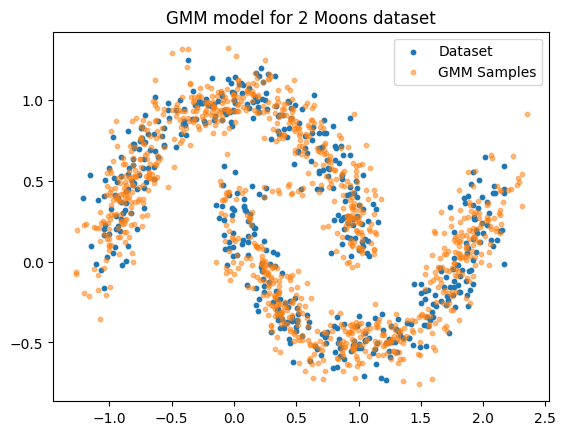

In [9]:
from scipy.stats import multivariate_normal

class gaussian_mixture_model:
    def __init__(self, n_terms = 1, steps = 100):
        self.mus = None
        self.Sigmas = None
        self.Pis = None
        self.samples = None
        self.score = None
        self.n_terms = n_terms
        self.steps = steps

    '''
    p_hat = sum_{m = 1}^M Pi_m N(mu_m, Sigma_m), where mu_m, Sigma_m
    can be found through expectation maximization algorithm from 1D.

    Basics:
    (0) Initialize Sigma_k = Id, mu_k random datapoint, Pi_k^(0) = 1 / M
    (1) for step t or until convergence:
        a) calc. performance
            gamma_ik^(t) = Pi_k^(t-1) N(x_i | mu_k^(t-1), Sigma_k^(t-1)) / p^(t-1)(x_i)
        b) update mu_k^(t), Sigma_k^(t)
            Pi_k^(t) = 1/N sum_{i=1}^N gamma_ik
            mu_k^(t) = sum_{i=1}^N gamma_ik x_i / sum_{i=1}^N gamma_ik
            Sigma_k^(t) ...
    '''

    def initialize_parameters(self, X):
        N, D = X.shape
        M = self.n_terms

        # Initialize for t = 0
        random_indices = np.random.choice(N, M, replace = False)
        self.mus = X[random_indices]
        self.Pis = np.ones(M) / M
        self.Sigmas = np.array([np.eye(D) for _ in range(M)])

    # Method to fit GMM
    def fit(self, X): # training_data := X
        
        # Initialize parameters
        self.initialize_parameters(X)
        self.N, self.D = X.shape
        self.M = self.n_terms

        # Expectation Maximization algorithm
        for t in range(self.steps):
            self.gamma_ik = np.zeros((self.N, self.M))
            # a) Calculate gamma_ik
            for k in range(self.M):
                self.gamma_ik[:, k] = self.Pis[k] * multivariate_normal.pdf(X, mean = self.mus[k], cov = self.Sigmas[k])

            # Normalize gamma_ik
            self.gamma_ik /= np.sum(self.gamma_ik, axis = 1, keepdims = True)
            
            # b) Update parameters
            # Calculate mus
            self.Pis = np.mean(self.gamma_ik, axis = 0)
            self.mus = (self.gamma_ik.T @ X) / np.sum(self.gamma_ik, axis = 0)[:, np.newaxis]
            # Calculate Sigmas: sum_i gamma_ik (x - mu)^T (x - mu) / sum_i gamma_ik
            # Define a small regularization constant to keep cov positive definite
            REG_COV = 1e-6
            for k in range(self.M):
                X_centered = X - self.mus[k]
                weighted_X_centered = X_centered * self.gamma_ik[:, k][:, np.newaxis]
                self.Sigmas[k] = weighted_X_centered.T @ X_centered / np.sum(self.gamma_ik[:, k], axis = 0) + REG_COV * np.eye(self.D)

        return self.mus, self.Sigmas
    
    def sample(self, n_samples):
        # Sample from GMM
        # 1. Pick from which Gaussian to sample based on weighs Pi_k
        component_indices = np.random.choice(self.M, size = n_samples, p = self.Pis)
        # Initialize samples array
        self.samples = np.zeros((n_samples, self.D))
        # 2. Sample from selected Gaussian
        for k in range(self.M):
            # Count instances where Gaussian k was selected
            n_k = np.sum(component_indices == k)
            if n_k > 0:
                self.samples[component_indices == k] = np.random.multivariate_normal(
                    self.mus[k], self.Sigmas[k], n_k)

        return self.samples
    
    # Method to score samplles
    def score_samples(self, X):
        """Compute the log density for each point in X."""
        if self.Pis is None or self.mus is None or self.Sigmas is None:
            raise ValueError("Model parameters are not initialized. Call `fit` first.")

        # Compute the weighted density for each component
        densities = np.zeros((X.shape[0], self.M))
        for k in range(self.M):
            densities[:, k] = self.Pis[k] * multivariate_normal.pdf(X, mean=self.mus[k], cov=self.Sigmas[k])

        # Sum the densities across components
        total_density = np.sum(densities, axis=1)

        # Return the log density
        log_density = np.log(total_density)
        return log_density

    # Method to evaluate
    def compute_mmd(self, X, h = 1, kernel = "squared_exponential"):
        # Implement MMD^2 metric with se, imq kernels
        # Need to vectorize MMD calculation because for loops (sums) are very inefficient in python
        # MMD^2 = Term1 + Term2 - Term3, can neglect Term1 because it is model independent
        """
        MMD^2 = 0
        for i in range(1,N):
            for i_prime != i:
                MMD^2 += k(x_i, x_i_prime)

        for j in range(1, N_prime):
            for j_prime != j:
                MMD^2 += k(x_prime_j, x_prime_j_prime)

        for i in range(1, N):
            for j in range(1, N_prime):
                MMD^2 += -2 k(x_i, x_prime_j)
        """
        # Instead, we want to calculate it using something like this:
        """
        MMD^2 = k(distance_matrix_x).sum() 
            + k(distance_matrix_x_prime).sum() 
            - 2 k(distance_matrix_xx_prime).sum()
        """
        # Calculate Distance matrices D as: 
        # D[i, j] = || x_i - x_i_prime ||_2^2 = ||x||_2^2 + ||x_prime||_2^2 - 2 x.T @ x_prime
        # D_XX = self.calculate_distance_matrix(X, X) Can be neglected
        D_XprimeXprime = self.calculate_distance_matrix(self.samples, self.samples)
        D_XXprime = self.calculate_distance_matrix(X, self.samples)

        # Depending on selected kernel, calculate MMD^2
        N = X.shape[0]
        Nprime = self.samples.shape[0]
        if kernel == "squared_exponential":
            MMD_sq = (self.squared_exponential(D_XprimeXprime, h).sum() / (Nprime ** 2)
                      - 2 * self.squared_exponential(D_XXprime, h).sum() / (N * Nprime))
        elif kernel == "inverse_multi_quadratic":
            MMD_sq = (self.inverse_multi_quadratic(D_XprimeXprime, h).sum() / (Nprime ** 2)
                      - 2 * self.inverse_multi_quadratic(D_XXprime, h).sum() / (N * Nprime))
        else:
            raise ValueError("Please select either 'squared_exponential' or 'inverse_multi_quadratic'")
        """
        In the lecture we derived the formula where we sum over i, then sum over i != j. The kernels 
        k(i, i) are not 0, but 1. We still sum over them in the vectorization. For that reason, 
        we adjust the denominator to N^2, N'^2 instead of N(N-1), N'(N'-1)
        """

        self.MMD_sq = MMD_sq

        return self.MMD_sq

    
    def calculate_distance_matrix(self, A, B):
        # D_ij = ||A_i - B_j||^2 = ||A_i||^2 + ||B_j||^2 - 2 A_i @ B_j.T
        # A_sq in (N_A, 1)
        A_sq = np.sum(A ** 2, axis = 1, keepdims = True)
        # B_sq in (1, N_B)
        B_sq = np.sum(B ** 2, axis = 1, keepdims = True).T # .T otherwise won't work if samples, data different dimension
        AB_T = A @ B.T
        D_AB = A_sq + B_sq - 2 * AB_T
        return D_AB
        
    def squared_exponential(self, D_AB, h):
        return exp(- D_AB / (h ** 2))   
    
    def inverse_multi_quadratic(self, D_AB, h):
        return 1 / sqrt(1 + D_AB / (h ** 2))

    

# Test GMM
model = gaussian_mixture_model(n_terms = 10, steps = 100)
make_moons_gmm = model.fit(X)

# Plot calculated GMM over data
samples = model.sample(1000)
plt.figure()
plt.title("GMM model for 2 Moons dataset")
plt.scatter(X[:, 0], X[:, 1], s=10, 
            label = "Dataset")
plt.scatter(samples[:, 0], samples[:, 1],
            alpha = 0.5, 
            s = 10, 
            label = "GMM Samples")
plt.legend()       
plt.show()

# Score

### Evaluation of Models


#### Steps:
1. Vary hyperparameters for each model (e.g., number of components for GMM).
2. Compute MMD for different bandwidths (`h`).
3. Visualize the results:
   - MMD values as a function of hyperparameters.
   - Density estimates and generated samples.

In [10]:
# Define data to train and test
X_train, _ = make_moons(n_samples = 1000, noise = 0.1, random_state = 42)
X_test, _ = make_moons(n_samples = 1000, random_state = 24)

#### 2D Histogram

/var/folders/dr/34chm7gn07vdb_w184vptt640000gn/T/ipykernel_70289/2696974575.py:98: RuntimeWarning: divide by zero encountered in log
  self.log_densities[valid_mask] = np.log(


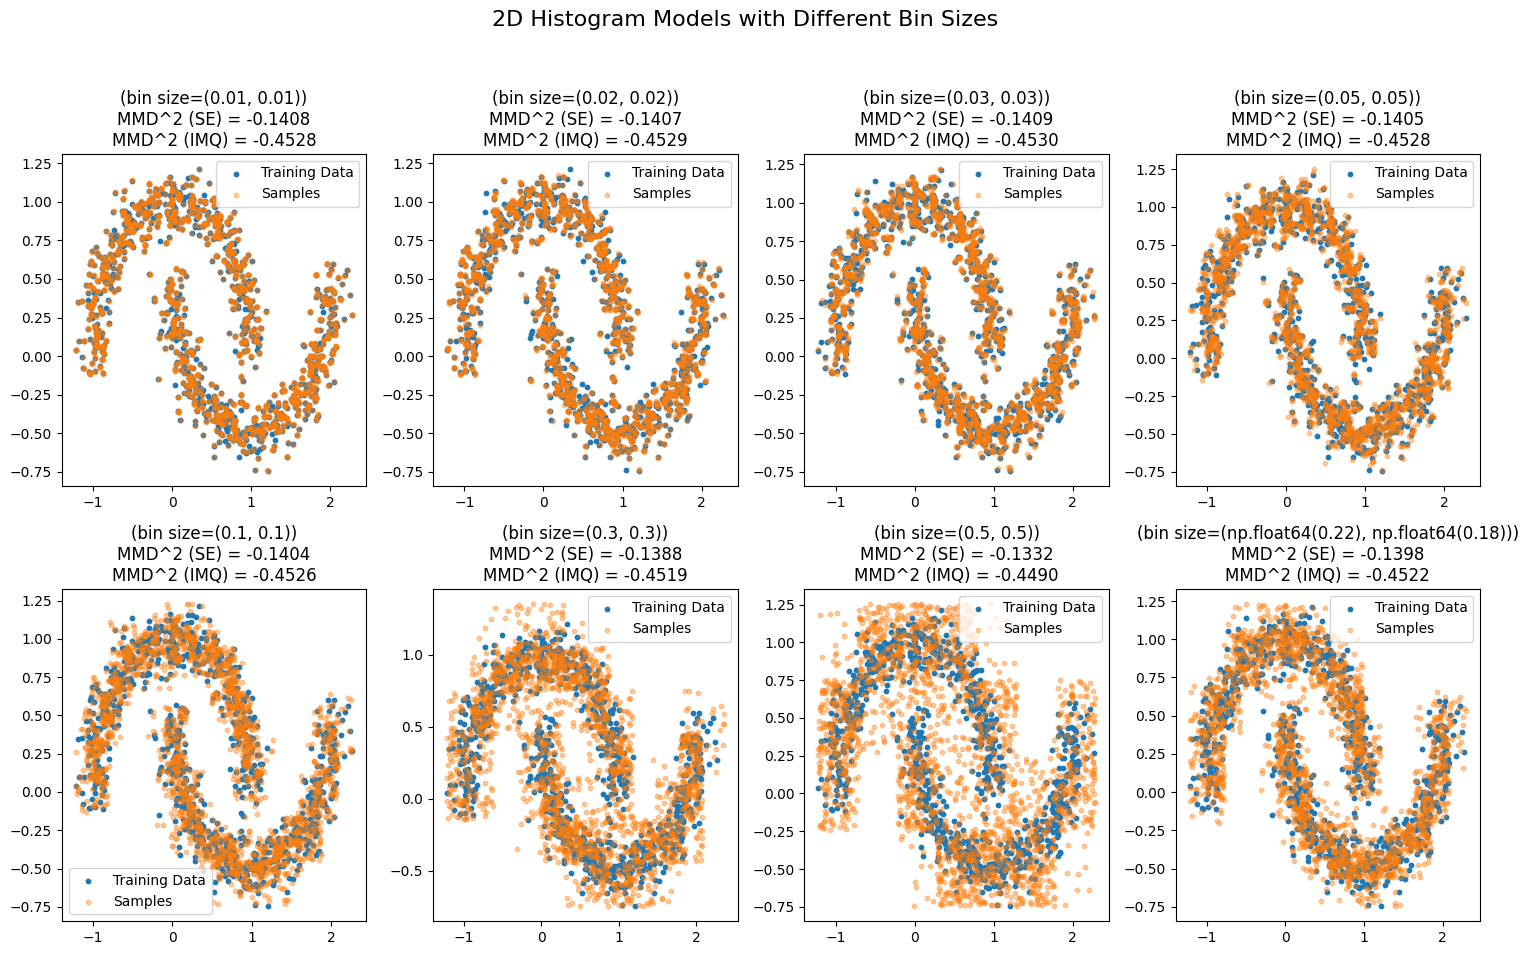

In [11]:
# Bin sizes
bin_sizes = [(0.01, 0.01), (0.02, 0.02), (0.03, 0.03), (0.05, 0.05), (0.1, 0.1), (0.3, 0.3), (0.5, 0.5), None]
results = {}
avg_bin_sizes = []
# Make a grid of plots
fig, axs = plt.subplots(2, 4, figsize=(15, 10))
fig.suptitle("2D Histogram Models with Different Bin Sizes", fontsize=16)
for bin_size in bin_sizes:
    model = two_dim_histogram(bin_size=bin_size)
    model.fit(X_train)
    model.sample(2000)
    model.score_samples(X_test)
    mmd_sq_se = model.compute_mmd(X_test, h = 0.5, kernel = "squared_exponential")
    mmd_sq_imq = model.compute_mmd(X_test, h = 0.5, kernel = "inverse_multi_quadratic")
    results[f"histogram_bin_size_{bin_size}"] = (mmd_sq_se, mmd_sq_imq)
    avg_bin_sizes.append(np.mean(model.bin_size))

    # Plotting
    ax = axs.flatten()[bin_sizes.index(bin_size)]
    X_samples = model.sample(n_samples = 2000)
    ax.scatter(X_train[:, 0], X_train[:, 1], s=10, label = "Training Data")
    ax.scatter(X_samples[:, 0], X_samples[:, 1], s=10, alpha = 0.4, label = "Samples")
    ax.set_title(f"(bin size={model.bin_size})\nMMD^2 (SE) = {mmd_sq_se:.4f}\nMMD^2 (IMQ) = {mmd_sq_imq:.4f}")
    ax.legend()

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


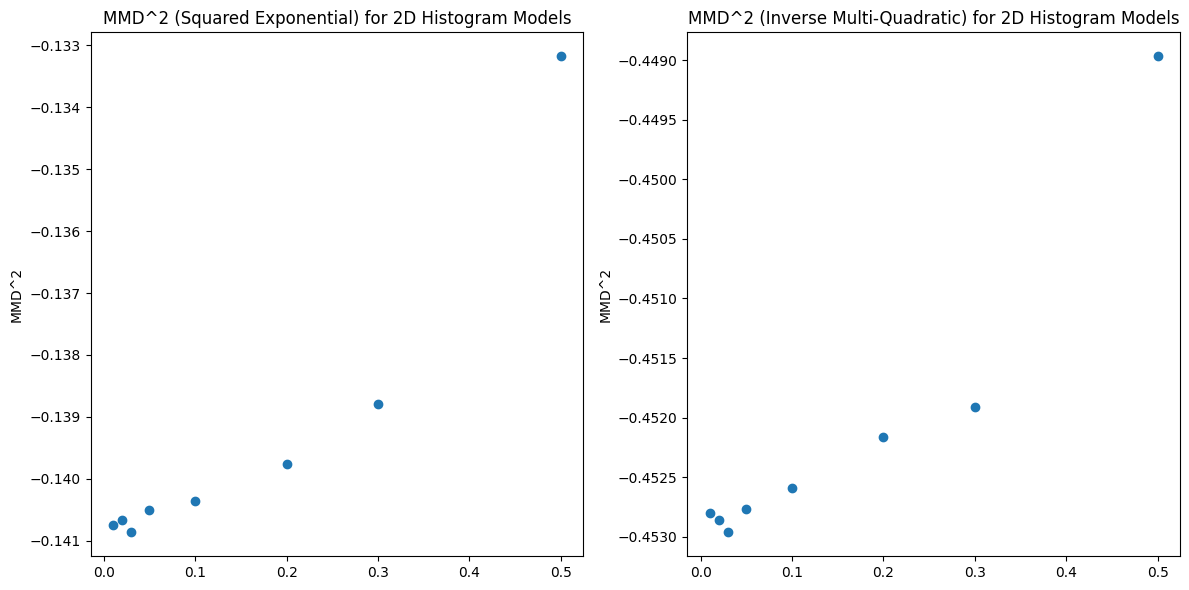

In [12]:
# Plot MMD^2 results for 2D histogram
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
# SE / IMQ
results_se = [results[key][0] for key in results]
results_imq = [results[key][1] for key in results]
axs[0].scatter(avg_bin_sizes, results_se)
axs[0].set_title("MMD^2 (Squared Exponential) for 2D Histogram Models")
axs[0].set_ylabel("MMD^2")
axs[1].scatter(avg_bin_sizes, results_imq)
axs[1].set_title("MMD^2 (Inverse Multi-Quadratic) for 2D Histogram Models")
axs[1].set_ylabel("MMD^2")
fig.tight_layout()
plt.show()

##### Comment on 2D Histogram results

Both kernels (se, imq) seem to find the same optimal solution among the selected ones at a bin_size of (0.05, 0.05) - (0.1, 0.1). Every run yields slightly different results, but consistently this range is among the best performing.

In 1d, the mathematically optimal solution calculates the Interquantile Range and determines from that the bin_size. In our case, it was of around (0.22, 0.18) which we plotted for simplicity purposes at an average of bin_size = 2. This does not seem to minimize the MMD^2 in two dimensions.

At a first glance, it appears as though bin_sizes that are too small overfit the model, so that it doesn't generalize when we use our test data.

#### GMM

-0.9262278252272135 -0.9641886501198736
-0.9262040728798719 -0.9641835821550444
-0.9261999175934569 -0.9641845377280958
-0.9261615565513167 -0.9641668693955826
-0.926173108627108 -0.9641722238043311
-0.9262269449547895 -0.9641967428562945
-0.9262097821911909 -0.9641895775623837
-0.9262289459263046 -0.9641985068872435


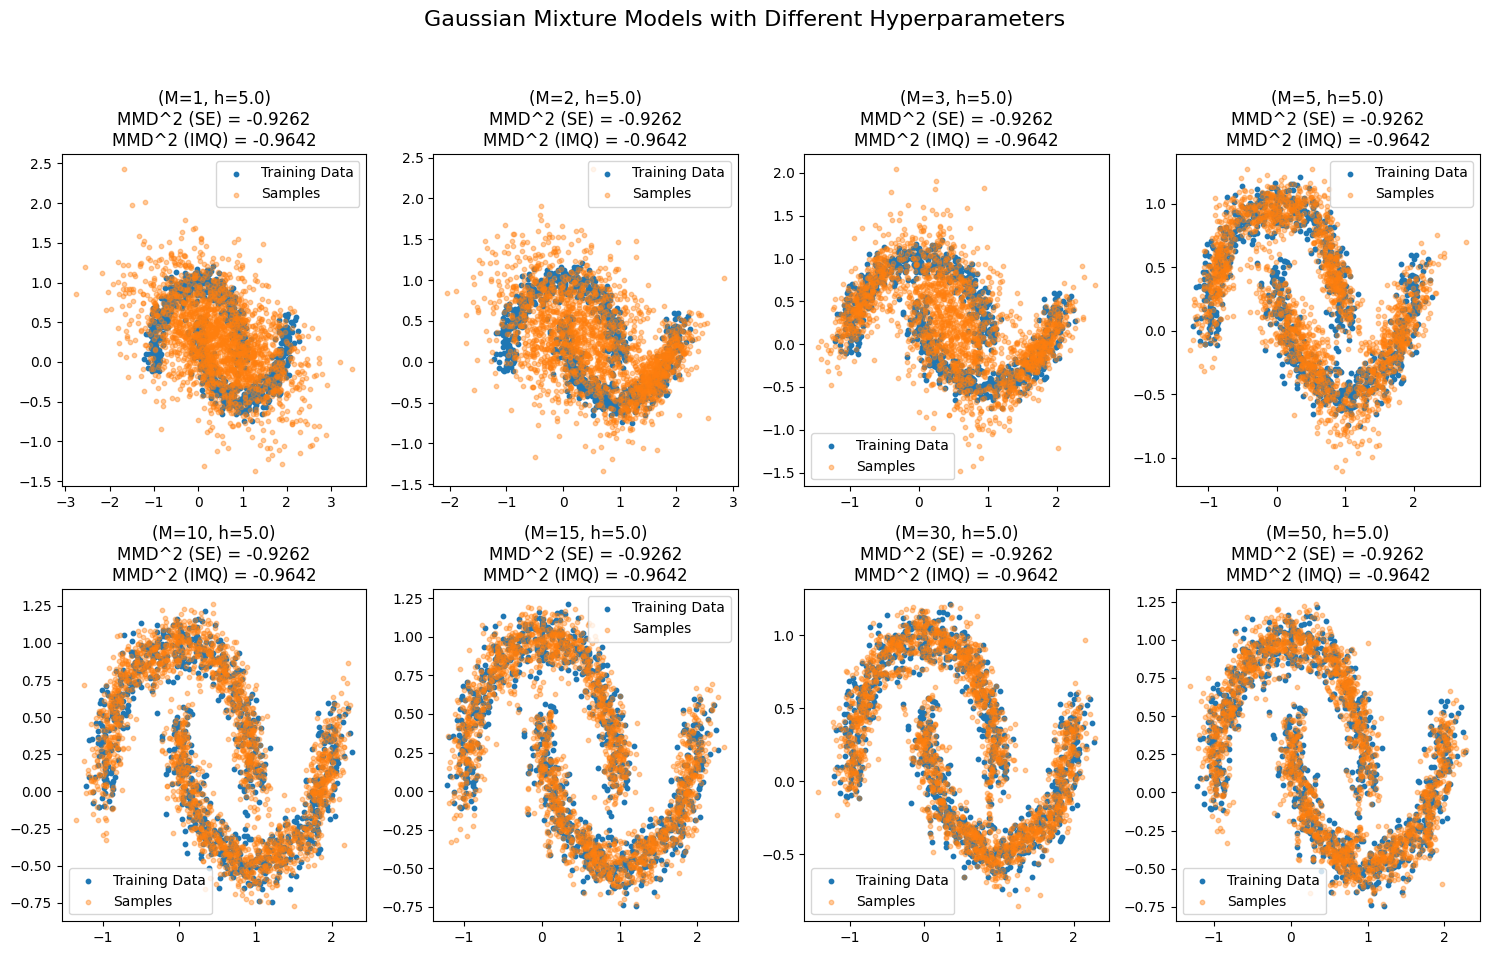

In [13]:
# Evaluate the GMM
# Bin sizes
Ms = [1, 2, 3, 5, 10, 15, 30, 50]
hs = [0.1, 0.2, 0.3, 0.5, 1.0, 1.5, 3.0, 5.0]

results = {}
# Make a grid of plots
fig, axs = plt.subplots(2, 4, figsize=(15, 10))
fig.suptitle("Gaussian Mixture Models with Different Hyperparameters", fontsize=16)
for M in Ms:
    for h in hs:
        model = gaussian_mixture_model(n_terms=M, steps=100)
        model.fit(X_train)
        model.sample(2000)
        model.score_samples(X_test)
        mmd_sq_se = model.compute_mmd(X_test, h=h, kernel="squared_exponential")
        mmd_sq_imq = model.compute_mmd(X_test, h=h, kernel="inverse_multi_quadratic")
        results[f"_{M}_{h}"] = (mmd_sq_se, mmd_sq_imq)
        if h == 5.0:
            print(mmd_sq_se, mmd_sq_imq)

    # Plotting (This will only plot for the last bandwidth but idc)
    ax = axs.flatten()[Ms.index(M)]
    X_samples = model.sample(n_samples=2000)
    ax.scatter(X_train[:, 0], X_train[:, 1], s=10, label="Training Data")
    ax.scatter(X_samples[:, 0], X_samples[:, 1], s=10, alpha=0.4, label="Samples")
    ax.set_title(f"(M={M}, h={h})\nMMD^2 (SE) = {mmd_sq_se:.4f}\nMMD^2 (IMQ) = {mmd_sq_imq:.4f}")
    ax.legend()

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


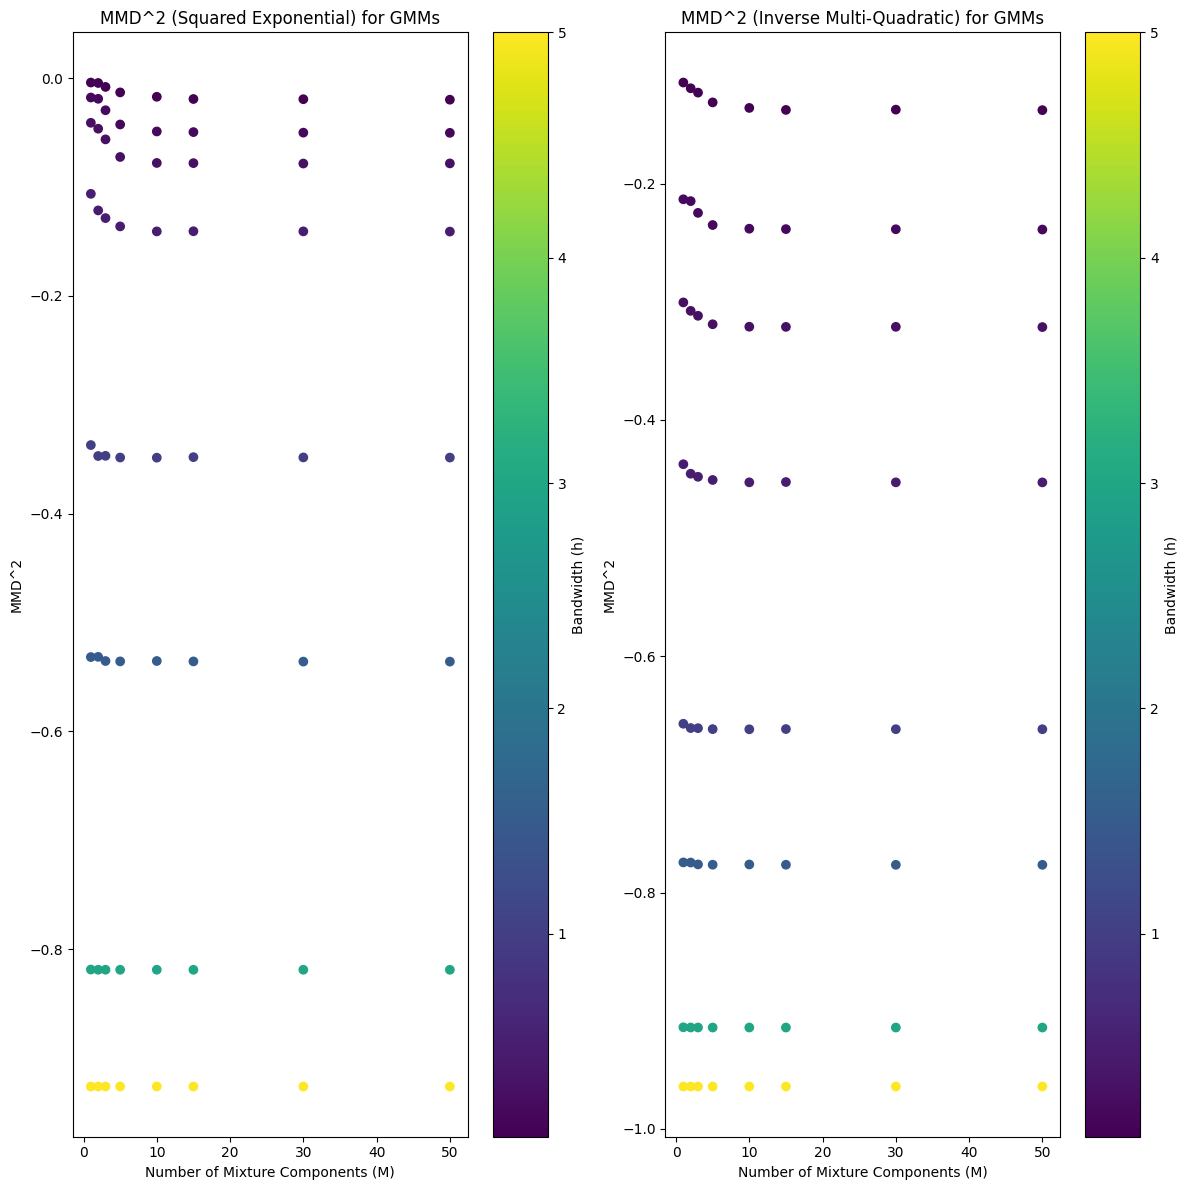

In [14]:
# Plot MMD^2 results for GMM
fig, axs = plt.subplots(1, 2, figsize=(12, 12))
# SE / IMQ
results_se = [results[key][0] for key in results]
results_imq = [results[key][1] for key in results]
Ms_list = [int(key.split("_")[1]) for key in results]
hs_list = [float(key.split("_")[2]) for key in results]
scatter1 = axs[0].scatter(Ms_list, results_se, c=hs_list, cmap='viridis')
axs[0].set_title("MMD^2 (Squared Exponential) for GMMs")
axs[0].set_xlabel("Number of Mixture Components (M)")
axs[0].set_ylabel("MMD^2")
cbar1 = fig.colorbar(scatter1, ax=axs[0])
cbar1.set_label('Bandwidth (h)')
scatter2 = axs[1].scatter(Ms_list, results_imq, c=hs_list, cmap='viridis')
axs[1].set_title("MMD^2 (Inverse Multi-Quadratic) for GMMs")
axs[1].set_xlabel("Number of Mixture Components (M)")
axs[1].set_ylabel("MMD^2")
cbar2 = fig.colorbar(scatter2, ax=axs[1])
cbar2.set_label('Bandwidth (h)')
fig.tight_layout()
plt.show()

##### Comment on GMM results

There are now multiple dimensions to this, because we test the model for different numbers of components and different bandwidths. We first comment on the total number of components, where at some point all models seem to converge. However, the models with larger bandwidth converge much faster which is totally weird because obviously for a small number of Gaussian terms, the model does not generalize well. Maybe a mistake in our calculation.

# 2. Higher dimensional data

In [15]:
# Import dataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Import Models
from sklearn.ensemble import RandomForestClassifier # In addition
from sklearn.neighbors import KDTree
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity

In [18]:
# Fit the models
# KDTree (instead of 2d Histogram)
kdtree = KDTree(X_train)
# GMM
gmm = GaussianMixture(n_components=10, random_state=42)
gmm.fit(X_train)
# KDE
kde = KernelDensity(kernel='gaussian', bandwidth=1.0)
kde.fit(X_train)
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
# Sample
n_samples = 1000
# KDTree Sampling
dist, indices = kdtree.query(X_train[np.random.choice(X_train.shape[0], n_samples)], k=1)
kdtree_samples = X_train[indices.flatten()]
# GMM Sampling
gmm_samples, _ = gmm.sample(n_samples)
# KDE Sampling
kde_samples = kde.sample(n_samples)
# Random Forest Sampling
rf_samples = rf.apply(X_train[np.random.choice(X_train.shape[0], n_samples)])
rf_samples = X_train[rf_samples[:, 0]]  # Using the first tree for sampling

In [23]:
# Compute MMD^2
def compute_mmd(X, h = 1, kernel = "squared_exponential"):
    # Implement MMD^2 metric with se, imq kernels
    # Need to vectorize MMD calculation because for loops (sums) are very inefficient in python
    # MMD^2 = Term1 + Term2 - Term3, can neglect Term1 because it is model independent
    """
    MMD^2 = 0
    for i in range(1,N):
        for i_prime != i:
            MMD^2 += k(x_i, x_i_prime)

    for j in range(1, N_prime):
        for j_prime != j:
            MMD^2 += k(x_prime_j, x_prime_j_prime)

    for i in range(1, N):
        for j in range(1, N_prime):
            MMD^2 += -2 k(x_i, x_prime_j)
    """
    # Instead, we want to calculate it using something like this:
    """
    MMD^2 = k(distance_matrix_x).sum() 
        + k(distance_matrix_x_prime).sum() 
        - 2 k(distance_matrix_xx_prime).sum()
    """
    # Calculate Distance matrices D as: 
    # D[i, j] = || x_i - x_i_prime ||_2^2 = ||x||_2^2 + ||x_prime||_2^2 - 2 x.T @ x_prime
    # D_XX = self.calculate_distance_matrix(X, X) Can be neglected
    D_XprimeXprime = calculate_distance_matrix(samples, samples)
    D_XXprime = calculate_distance_matrix(X, samples)

    # Depending on selected kernel, calculate MMD^2
    N = X.shape[0]
    Nprime = samples.shape[0]
    if kernel == "squared_exponential":
        MMD_sq = (squared_exponential(D_XprimeXprime, h).sum() / (Nprime ** 2)
                    - 2 * squared_exponential(D_XXprime, h).sum() / (N * Nprime))
    elif kernel == "inverse_multi_quadratic":
        MMD_sq = (inverse_multi_quadratic(D_XprimeXprime, h).sum() / (Nprime ** 2)
                    - 2 * inverse_multi_quadratic(D_XXprime, h).sum() / (N * Nprime))
    else:
        raise ValueError("Please select either 'squared_exponential' or 'inverse_multi_quadratic'")
    """
    In the lecture we derived the formula where we sum over i, then sum over i != j. The kernels 
    k(i, i) are not 0, but 1. We still sum over them in the vectorization. For that reason, 
    we adjust the denominator to N^2, N'^2 instead of N(N-1), N'(N'-1)
    """

    return MMD_sq

def calculate_distance_matrix(A, B):
    # D_ij = ||A_i - B_j||^2 = ||A_i||^2 + ||B_j||^2 - 2 A_i @ B_j.T
    # A_sq in (N_A, 1)
    A_sq = np.sum(A ** 2, axis = 1, keepdims = True)
    # B_sq in (1, N_B)
    B_sq = np.sum(B ** 2, axis = 1, keepdims = True).T # .T otherwise won't work if samples, data different dimension
    AB_T = A @ B.T
    D_AB = A_sq + B_sq - 2 * AB_T
    return D_AB

def squared_exponential(D_AB, h):
    return exp(- D_AB / (h ** 2))

def inverse_multi_quadratic(D_AB, h):
    return 1 / sqrt(1 + D_AB / (h ** 2))


In [38]:
# Compute MMD^2 for each model
models_samples = {
    "KDTree": kdtree_samples,
    "GMM": gmm_samples,
    "KDE": kde_samples,
    "Random Forest": rf_samples
}

mmd_results = {}
for model_name, samples in models_samples.items():
    mmd_sq_se = compute_mmd(X_test, h = 1.0, kernel = "squared_exponential")
    mmd_sq_imq = compute_mmd(X_test, h = 1.0, kernel = "inverse_multi_quadratic")
    mmd_results[model_name] = (mmd_sq_se, mmd_sq_imq)

print("MMD^2 Results for Different Models:")
for model_name, (mmd_se, mmd_imq) in mmd_results.items():
    print(f"{model_name}: MMD^2 (SE) = {mmd_se:.4f}, MMD^2 (IMQ) = {mmd_imq:.4f}")

MMD^2 Results for Different Models:
KDTree: MMD^2 (SE) = 0.0016, MMD^2 (IMQ) = -0.0199
GMM: MMD^2 (SE) = 0.0010, MMD^2 (IMQ) = -0.0204
KDE: MMD^2 (SE) = 0.0010, MMD^2 (IMQ) = -0.0204
Random Forest: MMD^2 (SE) = 0.0262, MMD^2 (IMQ) = 0.0044


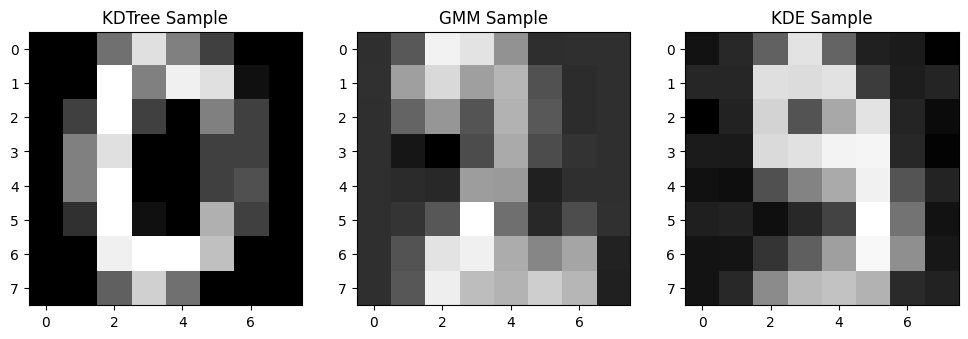

In [39]:
fig, axs = plt.subplots(1, 3, figsize=(12, 6))
for i in range(3):
    model_name = list(models_samples.keys())[i]
    samples = models_samples[model_name]
    axs[i].imshow(models_samples[model_name][0].reshape(8, 8), cmap='gray')
    axs[i].set_title(f"{model_name} Sample")

In [41]:
# Check model accuracy with RF
# Print score, accuracy
print("Random Forest Classifier Accuracy on Test Set:", rf.score(X_test, y_test))

Random Forest Classifier Accuracy on Test Set: 0.9722222222222222
